In [31]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [32]:
def f(x, y):
    return 10 - (x - 2) * np.exp(-(x - 2)) - (y - 3) * np.exp(-(y - 3))

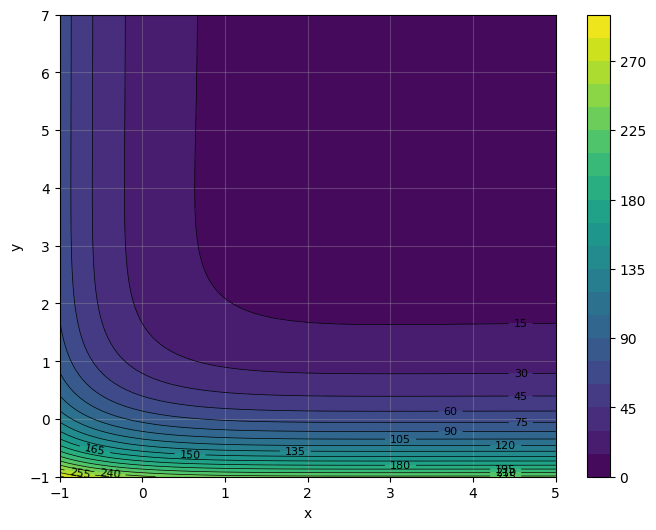

In [33]:
x = np.linspace(-1, 5, 100)
y = np.linspace(-1, 7, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

plt.figure(figsize=(8, 6))
cp = plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.colorbar(cp)
line_colors = plt.contour(X, Y, Z, levels=20, colors='black', linewidths=0.5)
plt.clabel(line_colors, inline=True, fontsize=8)

plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.show()

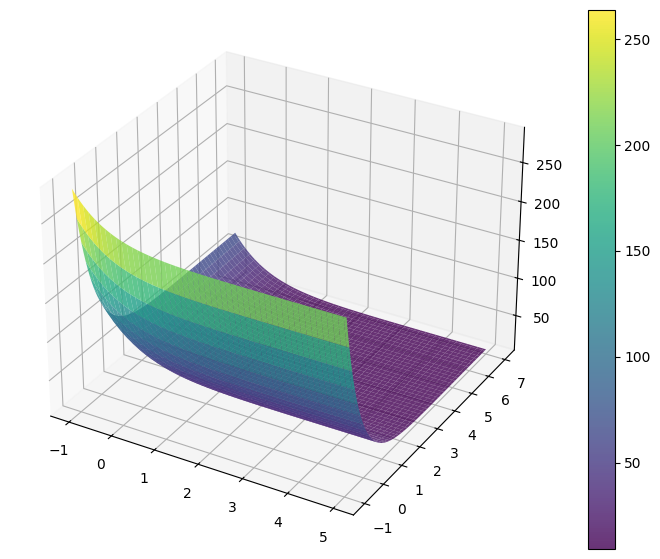

In [34]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
fig.colorbar(surf)
plt.show()

Алгоритм Золотого сечения из прошлой ЛР

In [35]:
def golden_section(f, a, b, eps):
    iterations = 0
    phi = 0.382
    x1 = a + phi * (b - a)
    x2 = b -  phi * (b - a)
    f1, f2 = f(x1), f(x2)
    
    while b - a > eps:
        iterations += 1
        if f1 > f2:
            a, x1, f1 = x1, x2, f2
            x2 = b - phi * (b - a)
            f2 = f(x2)
        else:
            b, x2, f2 = x2, x1, f1
            x1 = a + phi * (b - a)
            f1 = f(x1)
    
    return (a + b) / 2

In [36]:
def gauss_seidel(f, x0, eps=1e-6, max_iter=1000):
    x = np.array(x0, dtype=float)
    y = np.zeros(2)
    y[:] = x[:]
    
    k = 1
    j = 1
    
    history = [x.copy()]
    
    while k <= max_iter:
        x_prev = x.copy()
        
        while j <= 2:
            if j == 1:
                def f_lambda1(lambd):
                    return f(y[0] + lambd, y[1])
                
                lambda_opt = golden_section(f_lambda1, -5, 5, eps/10)
                
                y[0] = y[0] + lambda_opt
                
            else:
                def f_lambda2(lambd):
                    return f(y[0], y[1] + lambd)
                
                lambda_opt = golden_section(f_lambda2, -5, 5, eps/10)
                
                y[1] = y[1] + lambda_opt
            
            j += 1
            
            history.append(y.copy())
        
        x[:] = y[:]
        
        if np.linalg.norm(x - x_prev) < eps:
            print(f"Сходимость достигнута на итерации {k}")
            break
        
        y[:] = x[:]
        j = 1
        k += 1
    
    return x, history

In [37]:
def get_gradient(f, x, y, h=1e-8):
    grad_x = (f(x + h, y) - f(x - h, y)) / (2 * h)
    grad_y = (f(x, y + h) - f(x, y - h)) / (2 * h)
    return grad_x, grad_y

In [38]:
def steepest_descent(f, x0, eps=1e-6, max_iter=1000):
    x, y = float(x0[0]), float(x0[1])
    k = 1
    history = [(x, y)]
    
    print(f"{'Итер.':<7} | {'x':<10} | {'y':<10} | {'f(x,y)':<12} | {'||grad||':<10}")
    print("-" * 65)

    while k <= max_iter:
        gx, gy = get_gradient(f, x, y)
        grad_norm = np.sqrt(gx**2 + gy**2)
        
        if grad_norm < eps:
            print(f"Сходимость достигнута на итерации {k}")
            break
        
        sx = -gx / grad_norm
        sy = -gy / grad_norm
        
        def f_lambda(lmbd):
            return f(x + lmbd * sx, y + lmbd * sy)
        
        l_opt = golden_section(f_lambda, 0, 10, eps/10)
        
        x = x + l_opt * sx
        y = y + l_opt * sy
        
        history.append((x, y))
        
        if k % 1 == 0:
            print(f"{k:<7} | {x:<10.4f} | {y:<10.4f} | {f(x,y):<12.6f} | {grad_norm:<10.6f}")
            
        k += 1
        
    return (x, y), history

In [39]:
def visualize_optimization(f, history):
    x = np.linspace(-2, 6, 100)
    y = np.linspace(-2, 8, 100)
    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)
    
    fig = plt.figure(figsize=(15, 5))
    ax1 = fig.add_subplot(131, projection='3d')
    surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)
    ax1.scatter(history[0][0], history[0][1], f(history[0][0], history[0][1]), 
                color='red', s=100, marker='o', label='Начальная точка')
    
    history = np.array(history)
    ax1.plot(history[:, 0], history[:, 1], 
             [f(x, y) for x, y in history], 
             'r-', linewidth=2, markersize=5)
    ax1.scatter(history[-1][0], history[-1][1], f(history[-1][0], history[-1][1]), 
                color='green', s=100, marker='*', label='Оптимум')
    
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('f(X, Y)')
    ax1.set_title('3D визуализация метода')
    ax1.legend()
    
    ax2 = fig.add_subplot(132)
    contour = ax2.contour(X, Y, Z, levels=20, cmap='viridis')
    ax2.clabel(contour, inline=True, fontsize=8)
    ax2.plot(history[:, 0], history[:, 1], 'r.-', linewidth=2, markersize=5)
    ax2.scatter(history[0][0], history[0][1], color='red', s=100, marker='o', label='Начальная точка')
    ax2.scatter(history[-1][0], history[-1][1], color='green', s=100, marker='*', label='Оптимум')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_title('Траектория оптимизации')
    ax2.legend()
    ax2.grid(True)
    
    ax3 = fig.add_subplot(133)
    iterations = range(len(history))
    f_values = [f(x, y) for x, y in history]
    ax3.semilogy(iterations, [abs(val - f_values[-1]) for val in f_values], 'b.-')
    ax3.set_xlabel('Итерация')
    ax3.set_ylabel('|f(x) - f(x*)|')
    ax3.set_title('Сходимость метода')
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()

Итер.   | x          | y          | f(x,y)       | ||grad||  
-----------------------------------------------------------------
1       | 1.8233     | 8.5932     | 10.190020    | 284.567760
2       | 3.0006     | 8.5788     | 9.611050     | 1.404217  
3       | 2.9445     | 4.0007     | 9.264828     | 0.017295  
4       | 3.0000     | 4.0000     | 9.264241     | 0.021565  
5       | 3.0000     | 4.0000     | 9.264241     | 0.000014  
Сходимость достигнута на итерации 6
Найденный оптимум: x* = [3.000000, 4.000000]
Значение функции: f(x*) = 9.264241
Теоретический оптимум: x = [2, 3]
Количество итераций (точек): 6
Погрешность по x: 1.00e+00
Погрешность по y: 1.00e+00


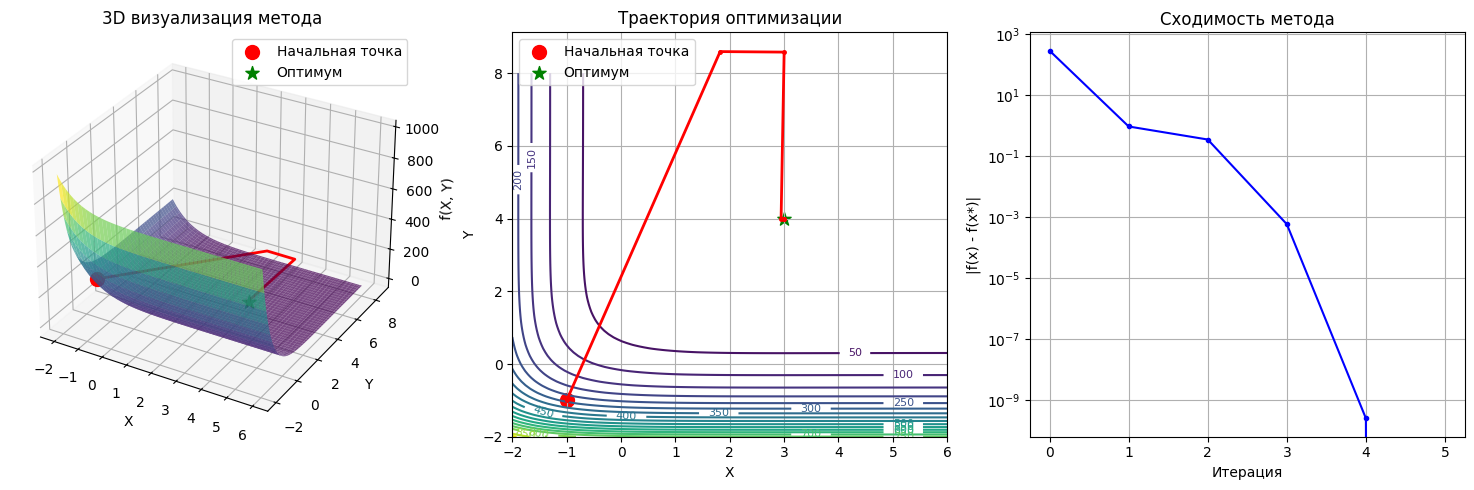

№    x               y               f(x,y)         
0    -1.0            -1.0            288.649        
2    3.00058         8.57883         9.61105        
4    3.0             4.00004         9.26424        
5    3.0             4.0             9.26424        


In [40]:
eps = 1e-6
x0 = [-1, -1]
x_opt, history = steepest_descent(f, x0, eps)

print(f"Найденный оптимум: x* = [{x_opt[0]:.6f}, {x_opt[1]:.6f}]")
print(f"Значение функции: f(x*) = {f(x_opt[0], x_opt[1]):.6f}")
print(f"Теоретический оптимум: x = [2, 3]")
print(f"Количество итераций (точек): {len(history)}")
print(f"Погрешность по x: {abs(x_opt[0] - 2):.2e}")
print(f"Погрешность по y: {abs(x_opt[1] - 3):.2e}")

visualize_optimization(f, history)

print(f"{'№':<4} {'x':<15} {'y':<15} {'f(x,y)':<15}")

for i, point in enumerate(history):
    if i % 2 == 0 or i == len(history) - 1:
        print(f"{i:<4} {point[0]:<15.6} {point[1]:<15.6} {f(point[0], point[1]):<15.6}")